# DBSCAN

Vamos a utilizar DBSCAN para mostrar clusters de museos en Argentina

### SETUP
Descargamos e importamos las dependencias.

In [ ]:
# Descargamos dependencias
!pip install -q numpy==2.2.0
!pip install -q pandas==2.2.3
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3
!pip install -q hdbscan==0.8.40
!pip install -q geopandas==1.0.1
!pip install -q contextily==1.6.2
!pip install -q shapely==2.0.6

In [64]:
#Importamos dependencias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
import requests
import io
import os
import rasterio
from rasterio.transform import from_bounds

import geopandas as gpd  # un pseudo-dataframe de pandas para ubicaciones geograficas 

import warnings
warnings.filterwarnings('ignore')

En este caso el curso original utilizaba un dataset de Canada pero me pareció interesante llevarlo a un contexto nacional, por lo que voy a utilizar un dataset descargado de [datos.cultura.gob](https://datos.cultura.gob.ar/dataset/espacios-culturales-argentina-sinca/archivo/4207def0-2ff7-41d5-9095-d42ae8207a5d) y un archivo .tif de [NASA](https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi) .

In [65]:
# "Limite" de Argentina
WEST, SOUTH, EAST, NORTH = -73.6, -55.1, -53.6, -21.8
WIDTH, HEIGHT = 2048, 3072

WMS_URL = "https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi"

params = {
    "SERVICE": "WMS",
    "VERSION": "1.1.1",
    "REQUEST": "GetMap",
    "LAYERS": "BlueMarble_NextGeneration",
    "STYLES": "",
    "FORMAT": "image/tiff",       
    "TRANSPARENT": "false",
    "WIDTH": str(WIDTH),
    "HEIGHT": str(HEIGHT),
    "SRS": "EPSG:4326",
    "BBOX": f"{WEST},{SOUTH},{EAST},{NORTH}",
    "TIME": "2004-01-01",
}

output_path = os.path.join("Argentina.tif")

print("Obteniendo geotiff de Argentina")
response = requests.get(WMS_URL, params=params)
response.raise_for_status()

image_data = np.array(__import__('PIL').Image.open(io.BytesIO(response.content)))  # (H, W, 3)

transform = from_bounds(WEST, SOUTH, EAST, NORTH, WIDTH, HEIGHT)

with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=HEIGHT,
    width=WIDTH,
    count=3,              
    dtype=image_data.dtype,
    crs='EPSG:4326',       
    transform=transform    
) as dst:
    dst.write(image_data[:, :, 0], 1)  # R
    dst.write(image_data[:, :, 1], 2)  # G
    dst.write(image_data[:, :, 2], 3)  # B

print(f"GeoTIFF guardado: {output_path}")

Obteniendo geotiff de Argentina
GeoTIFF guardado: Argentina.tif


Por último, definimos una función para utilizar más adelante, cunado necesitemos mappear los puntos al archivo GeoTIFF.

In [66]:
from rasterio.plot import show

def plot_clustered_locations(df, title='Museums Clustered by Proximity'):
    # Load coordinates into a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitud'], df['Latitud']), crs="EPSG:4326")

    _, ax = plt.subplots(figsize=(15, 10))

    # Draw the GeoTIFF background directly 
    with rasterio.open('./Argentina.tif') as src:
        show(src, ax=ax)

    # Plot on top in EPSG:4326 
    non_noise = gdf[gdf['Cluster'] != -1]
    noise     = gdf[gdf['Cluster'] == -1]

    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)

    plt.title(title)
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

## Estudio del Dataset
Ahora, como ya tenemos el dataset descargado podemos leerlo y hacer un breve analisis de su formato.

In [67]:
df = pd.read_csv('../museos_datosabiertos.csv')
df.dtypes

Cod_Loc                  int64
IdProvincia              int64
IdDepartamento           int64
Observaciones          float64
categoria               object
subcategoria            object
provincia               object
localidad               object
nombre                  object
direccion               object
piso                   float64
CP                      object
cod_area               float64
telefono                object
Mail                    object
Web                     object
Latitud                float64
Longitud               float64
TipoLatitudLongitud     object
Info_adicional          object
fuente                  object
jurisdiccion            object
año_inauguracion       float64
actualizacion            int64
dtype: object

## Procesamiento del Dataset

En este ejemplo queremos simplemente encontrar clusters en base a su ubicación geografica, por lo tanto no vamos a necesitar mas datos que su Latitud y Longitud, es importante asegurarnos de que ningún registro tenga esos campos incompletos.



In [68]:
# Armamos dataframe con "features" importantes
x = df[["Latitud","Longitud"]]
# Excluimos registros con campos vacíos
x = x.dropna()

x

,Latitud,Longitud
0,-35.441762,-60.887598
1,-34.066970,-60.102555
2,-29.118024,-59.654543
3,-34.662110,-58.363270
4,-36.781824,-59.858636
...,...,...
1177,-26.852880,-65.712622
1178,-26.683331,-65.266670
1179,-26.740733,-65.263231
1180,-21.937642,-66.052043


## Construccion del Modelo
Antes de realmente armar el modelo y teniendo en cuenta que DBSCAN es sensible a la escala de los puntos tenemos que acomodar la escala de nuestra información, por otro lado recordemos que hay una serie de parametros a definir manualmente que impactan en la clusterización final.

In [69]:
# Acomodamos escala
coords_scaled = x.copy()
coords_scaled["Latitud"] = 2*coords_scaled["Latitud"]

# Definimos parametros
min_samples=3 # Samples minimos para formar un vecindario
eps=1.0 # Radio de vecindario
metric='euclidean'  

# Armamos modelo
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(coords_scaled)

Teniendo el modelo podemos agregarle a cada registro el cluster que le asignó, para poder visualizarlos en el GeoTIFF con facilidad.

In [70]:
# Agregamos cluster a cada punto
x['Cluster'] = dbscan.fit_predict(coords_scaled)

## Estudio de Resultados
Una vez hecho esto -y gracias a la función declarada anteriormente- podemos obtener el tamaño de cada cluster, así como superponer los puntos con la imagen de Argentina para estudiar su distribución espacial.

Cluster
 0     621
 8     148
-1      53
 4      48
 19     46
 9      32
 17     32
 23     29
 11     20
 14     18
 13     13
 26     12
 3      10
 16     10
 10      9
 2       8
 24      8
 28      8
 7       7
 20      7
 12      6
 22      6
 27      6
 15      4
 18      4
 5       4
 25      4
 6       3
 21      3
 1       3
Name: count, dtype: int64


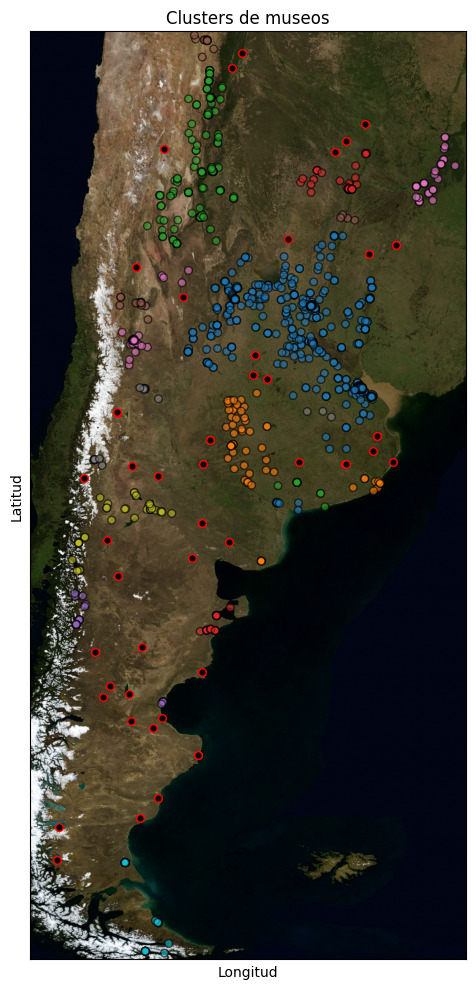

In [71]:
# Vemos tamaño de cada cluster
print(x['Cluster'].value_counts())

# Superponemos puntos y GeoTIFF
plot_clustered_locations(x, title='Clusters de museos')

Es evidente que tenemos una serie de clusters excesivamente grandes, en particular la región bonaerense se extiende a distintas provincias centrales y esto es claramente un error de agrupamiento, probablemente causado por una mala categorización de los puntos "noise" que impiden crear nuevos clusters. Pasemos entonces a un estudio identico, pero utilizando [HDBSCAN](../HDBSCAN/HDBSCAN.ipynb)